In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ruta = "../data/raw/mercado_inmobiliario_bogota.csv"

df = pd.read_csv(ruta)

df.head()

,MES,UNIDADES_VENDIDAS_TOTAL,UNIDADES_VENDIDAS_VIP,UNIDADES_VENDIDAS_VIS,UNIDADES_VENDIDAS_NO_VIS,UNIDADES_DISPONIBLES_TOTAL,UNIDADES_DISPONIBLES_VIP,UNIDADES_DISPONIBLES_VIS,UNIDADES_DISPONIBLES_NO_VIS,UNIDADES_LANZADAS_TOTAL,...,VALOR_VENDIDAS_VIS,VALOR_VENDIDAS_NO_VIS,VALOR_DISPONIBLES_TOTAL,VALOR_DISPONIBLES_VIP,VALOR_DISPONIBLES_VIS,VALOR_DISPONIBLES_NO_VIS,VALOR_LANZADAS_TOTAL,VALOR_LANZADAS_VIP,VALOR_LANZADAS_VIS,VALOR_LANZADAS_NO_VIS
0,06/01/2004 12:00:00 AM,2204,624,729,851,12604,3273,3094,6237,2136,...,30672,133806,1288183,74934,132384,1080866,134962,17158.0,22525,95279
1,07/01/2004 12:00:00 AM,2539,823,800,916,13226,4013,2911,6302,3157,...,33761,176174,1317737,88973,125865,1102899,240779,32504.0,26282,181993
2,08/01/2004 12:00:00 AM,2917,1097,923,897,13717,4211,2800,6706,3408,...,37824,115746,1378824,91421,120346,1167056,232316,26344.0,31491,174480
3,09/01/2004 12:00:00 AM,3036,1309,790,937,14024,4577,2632,6815,3338,...,32541,149393,1388409,98948,112012,1177449,214316,35352.0,24133,154831
4,10/01/2004 12:00:00 AM,3201,1106,916,1179,13338,4034,2075,7229,2515,...,37707,202538,1457812,87241,92260,1278311,324537,12364.0,17711,294462


In [3]:
df.shape

(181, 37)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   MES                          181 non-null    str    
 1   UNIDADES_VENDIDAS_TOTAL      181 non-null    int64  
 2   UNIDADES_VENDIDAS_VIP        181 non-null    int64  
 3   UNIDADES_VENDIDAS_VIS        181 non-null    int64  
 4   UNIDADES_VENDIDAS_NO_VIS     181 non-null    int64  
 5   UNIDADES_DISPONIBLES_TOTAL   181 non-null    int64  
 6   UNIDADES_DISPONIBLES_VIP     181 non-null    int64  
 7   UNIDADES_DISPONIBLES_VIS     181 non-null    int64  
 8   UNIDADES_DISPONIBLES_NO_VIS  181 non-null    int64  
 9   UNIDADES_LANZADAS_TOTAL      181 non-null    int64  
 10  UNIDADES_LANZADAS_VIP        178 non-null    float64
 11  UNIDADES_LANZADAS_VIS        181 non-null    int64  
 12  UNIDADES_LANZADAS_NO_VIS     181 non-null    int64  
 13  AREA_VENDIDAS_TOTAL          18

In [5]:
df.isna().sum()

MES                            0
UNIDADES_VENDIDAS_TOTAL        0
UNIDADES_VENDIDAS_VIP          0
UNIDADES_VENDIDAS_VIS          0
UNIDADES_VENDIDAS_NO_VIS       0
UNIDADES_DISPONIBLES_TOTAL     0
UNIDADES_DISPONIBLES_VIP       0
UNIDADES_DISPONIBLES_VIS       0
UNIDADES_DISPONIBLES_NO_VIS    0
UNIDADES_LANZADAS_TOTAL        0
UNIDADES_LANZADAS_VIP          3
UNIDADES_LANZADAS_VIS          0
UNIDADES_LANZADAS_NO_VIS       0
AREA_VENDIDAS_TOTAL            0
AREA_VENDIDAS_VIP              0
AREA_VENDIDAS_VIS              0
AREA_VENDIDAS_NO_VIS           0
AREA_DISPONIBLES_TOTAL         0
AREA_DISPONIBLES_VIP           0
AREA_DISPONIBLES_VIS           0
AREA_DISPONIBLES_NO_VIS        0
AREA_LANZADAS_TOTAL            0
AREA_LANZADAS_VIP              3
AREA_LANZADAS_VIS              0
AREA_LANZADAS_NO_VIS           0
VALOR_VENDIDAS_TOTAL           0
VALOR_VENDIDAS_VIP             0
VALOR_VENDIDAS_VIS             0
VALOR_VENDIDAS_NO_VIS          0
VALOR_DISPONIBLES_TOTAL        0
VALOR_DISP

In [6]:
df["MES"].head(10)

0    06/01/2004 12:00:00 AM
1    07/01/2004 12:00:00 AM
2    08/01/2004 12:00:00 AM
3    09/01/2004 12:00:00 AM
4    10/01/2004 12:00:00 AM
5    11/01/2004 12:00:00 AM
6    12/01/2004 12:00:00 AM
7    01/01/2005 12:00:00 AM
8    02/01/2005 12:00:00 AM
9    03/01/2005 12:00:00 AM
Name: MES, dtype: str

In [7]:
df["MES"] = pd.to_datetime(
    df["MES"],
    format="%m/%d/%Y %I:%M:%S %p"
)

df["MES"].head()

0   2004-06-01
1   2004-07-01
2   2004-08-01
3   2004-09-01
4   2004-10-01
Name: MES, dtype: datetime64[us]

In [8]:
print("Fecha inicial:", df["MES"].min())
print("Fecha final:", df["MES"].max())

Fecha inicial: 2004-06-01 00:00:00
Fecha final: 2019-06-01 00:00:00


In [9]:
columnas_con_nulos = df.columns[df.isna().any()]

df.loc[df[columnas_con_nulos].isna().any(axis=1), ["MES"] + list(columnas_con_nulos)]

,MES,UNIDADES_LANZADAS_VIP,AREA_LANZADAS_VIP,VALOR_LANZADAS_VIP
92,2012-02-01,NaN,NaN,NaN
95,2012-05-01,NaN,NaN,NaN
102,2012-12-01,NaN,NaN,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["MES"].duplicated().sum()

np.int64(0)

In [12]:
fechas_esperadas = pd.date_range(
    start=df["MES"].min(),
    end=df["MES"].max(),
    freq="MS"
)

fechas_faltantes = fechas_esperadas.difference(df["MES"])

fechas_faltantes

DatetimeIndex([], dtype='datetime64[us]', freq='MS')

In [13]:
control_vendidas = (
    df["UNIDADES_VENDIDAS_VIP"]
    + df["UNIDADES_VENDIDAS_VIS"]
    + df["UNIDADES_VENDIDAS_NO_VIS"]
)

(control_vendidas == df["UNIDADES_VENDIDAS_TOTAL"]).value_counts()

True    181
Name: count, dtype: int64

In [14]:
columnas_revision = [
    "MES",
    "UNIDADES_LANZADAS_TOTAL",
    "UNIDADES_LANZADAS_VIP",
    "UNIDADES_LANZADAS_VIS",
    "UNIDADES_LANZADAS_NO_VIS",
    "AREA_LANZADAS_TOTAL",
    "AREA_LANZADAS_VIP",
    "AREA_LANZADAS_VIS",
    "AREA_LANZADAS_NO_VIS",
    "VALOR_LANZADAS_TOTAL",
    "VALOR_LANZADAS_VIP",
    "VALOR_LANZADAS_VIS",
    "VALOR_LANZADAS_NO_VIS"
]

df.loc[df["UNIDADES_LANZADAS_VIP"].isna(), columnas_revision]

,MES,UNIDADES_LANZADAS_TOTAL,UNIDADES_LANZADAS_VIP,UNIDADES_LANZADAS_VIS,UNIDADES_LANZADAS_NO_VIS,AREA_LANZADAS_TOTAL,AREA_LANZADAS_VIP,AREA_LANZADAS_VIS,AREA_LANZADAS_NO_VIS,VALOR_LANZADAS_TOTAL,VALOR_LANZADAS_VIP,VALOR_LANZADAS_VIS,VALOR_LANZADAS_NO_VIS
92,2012-02-01,2732,NaN,785,1947,180327,NaN,37901,142426,545735,NaN,57145,488590
95,2012-05-01,2076,NaN,609,1467,146837,NaN,29308,117529,508037,NaN,43845,464192
102,2012-12-01,1803,NaN,610,1193,127316,NaN,30212,97104,488754,NaN,49977,438777


In [15]:
df["check_unidades_lanzadas"] = (
    df["UNIDADES_LANZADAS_VIS"].fillna(0)
    + df["UNIDADES_LANZADAS_NO_VIS"].fillna(0)
    + df["UNIDADES_LANZADAS_VIP"].fillna(0)
)

df["check_area_lanzadas"] = (
    df["AREA_LANZADAS_VIS"].fillna(0)
    + df["AREA_LANZADAS_NO_VIS"].fillna(0)
    + df["AREA_LANZADAS_VIP"].fillna(0)
)

df["check_valor_lanzadas"] = (
    df["VALOR_LANZADAS_VIS"].fillna(0)
    + df["VALOR_LANZADAS_NO_VIS"].fillna(0)
    + df["VALOR_LANZADAS_VIP"].fillna(0)
)

In [16]:
print(
    "Unidades:",
    (df["check_unidades_lanzadas"] == df["UNIDADES_LANZADAS_TOTAL"]).sum(),
    "de",
    len(df)
)

print(
    "Área:",
    (df["check_area_lanzadas"] == df["AREA_LANZADAS_TOTAL"]).sum(),
    "de",
    len(df)
)

print(
    "Valor:",
    (df["check_valor_lanzadas"] == df["VALOR_LANZADAS_TOTAL"]).sum(),
    "de",
    len(df)
)

Unidades: 181 de 181
Área: 156 de 181
Valor: 122 de 181


In [17]:
df["UNIDADES_LANZADAS_VIP"] = df["UNIDADES_LANZADAS_VIP"].fillna(0)

In [18]:
meses_nulos = df["AREA_LANZADAS_VIP"].isna()

df.loc[
    meses_nulos,
    [
        "MES",
        "AREA_LANZADAS_TOTAL",
        "AREA_LANZADAS_VIP",
        "AREA_LANZADAS_VIS",
        "AREA_LANZADAS_NO_VIS",
        "VALOR_LANZADAS_TOTAL",
        "VALOR_LANZADAS_VIP",
        "VALOR_LANZADAS_VIS",
        "VALOR_LANZADAS_NO_VIS"
    ]
]

,MES,AREA_LANZADAS_TOTAL,AREA_LANZADAS_VIP,AREA_LANZADAS_VIS,AREA_LANZADAS_NO_VIS,VALOR_LANZADAS_TOTAL,VALOR_LANZADAS_VIP,VALOR_LANZADAS_VIS,VALOR_LANZADAS_NO_VIS
92,2012-02-01,180327,NaN,37901,142426,545735,NaN,57145,488590
95,2012-05-01,146837,NaN,29308,117529,508037,NaN,43845,464192
102,2012-12-01,127316,NaN,30212,97104,488754,NaN,49977,438777


In [19]:
df["DIF_AREA_LANZADAS"] = (
    df["AREA_LANZADAS_TOTAL"]
    - (
        df["AREA_LANZADAS_VIS"].fillna(0)
        + df["AREA_LANZADAS_NO_VIS"].fillna(0)
        + df["AREA_LANZADAS_VIP"].fillna(0)
    )
)

In [20]:
df["DIF_VALOR_LANZADAS"] = (
    df["VALOR_LANZADAS_TOTAL"]
    - (
        df["VALOR_LANZADAS_VIS"].fillna(0)
        + df["VALOR_LANZADAS_NO_VIS"].fillna(0)
        + df["VALOR_LANZADAS_VIP"].fillna(0)
    )
)

In [21]:
df["DIF_AREA_LANZADAS"].describe()

count    181.000000
mean      -0.049724
std        0.369327
min       -1.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: DIF_AREA_LANZADAS, dtype: float64

In [22]:
df["DIF_VALOR_LANZADAS"].describe()

count    181.000000
mean       0.038674
std        0.571204
min       -1.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: DIF_VALOR_LANZADAS, dtype: float64

In [23]:
df.loc[
    df["DIF_AREA_LANZADAS"] != 0,
    ["MES", "DIF_AREA_LANZADAS"]
].head(20)

,MES,DIF_AREA_LANZADAS
58,2009-04-01,-1.0
65,2009-11-01,1.0
71,2010-05-01,1.0
80,2011-02-01,-1.0
81,2011-03-01,-1.0
85,2011-07-01,-1.0
100,2012-10-01,1.0
104,2013-02-01,-1.0
115,2014-01-01,1.0
118,2014-04-01,-1.0


In [24]:
df.loc[
    df["DIF_VALOR_LANZADAS"] != 0,
    ["MES", "DIF_VALOR_LANZADAS"]
].head(20)

,MES,DIF_VALOR_LANZADAS
2,2004-08-01,1.0
5,2004-11-01,1.0
6,2004-12-01,1.0
7,2005-01-01,-1.0
12,2005-06-01,-1.0
13,2005-07-01,-1.0
16,2005-10-01,1.0
19,2006-01-01,1.0
20,2006-02-01,1.0
22,2006-04-01,-1.0


In [25]:
columnas_vip_nulas = [
    "UNIDADES_LANZADAS_VIP",
    "AREA_LANZADAS_VIP",
    "VALOR_LANZADAS_VIP"
]

df[columnas_vip_nulas] = df[columnas_vip_nulas].fillna(0)

In [26]:
df.isna().sum().sum()

np.int64(0)

1. Valor promedio por vivienda vendida

In [27]:
df["VALOR_PROMEDIO_VIVIENDA_TOTAL"] = (
    df["VALOR_VENDIDAS_TOTAL"] / df["UNIDADES_VENDIDAS_TOTAL"]
)

In [28]:
df["VALOR_PROMEDIO_VIVIENDA_VIS"] = (
    df["VALOR_VENDIDAS_VIS"] / df["UNIDADES_VENDIDAS_VIS"]
)

df["VALOR_PROMEDIO_VIVIENDA_NO_VIS"] = (
    df["VALOR_VENDIDAS_NO_VIS"] / df["UNIDADES_VENDIDAS_NO_VIS"]
)

In [29]:
df["VALOR_PROMEDIO_VIVIENDA_VIP"] = (
    df["VALOR_VENDIDAS_VIP"] / df["UNIDADES_VENDIDAS_VIP"]
)

2. Valor aproximado por m²

In [30]:
df["VALOR_M2_TOTAL"] = (
    df["VALOR_VENDIDAS_TOTAL"] / df["AREA_VENDIDAS_TOTAL"]
)

df["VALOR_M2_VIS"] = (
    df["VALOR_VENDIDAS_VIS"] / df["AREA_VENDIDAS_VIS"]
)

df["VALOR_M2_NO_VIS"] = (
    df["VALOR_VENDIDAS_NO_VIS"] / df["AREA_VENDIDAS_NO_VIS"]
)

df["VALOR_M2_VIP"] = (
    df["VALOR_VENDIDAS_VIP"] / df["AREA_VENDIDAS_VIP"]
)

3. Tasa de absorción

In [31]:
df["TASA_ABSORCION_TOTAL"] = (
    df["UNIDADES_VENDIDAS_TOTAL"] / df["UNIDADES_DISPONIBLES_TOTAL"]
)

In [32]:
df["TASA_ABSORCION_VIS"] = (
    df["UNIDADES_VENDIDAS_VIS"] / df["UNIDADES_DISPONIBLES_VIS"]
)

df["TASA_ABSORCION_NO_VIS"] = (
    df["UNIDADES_VENDIDAS_NO_VIS"] / df["UNIDADES_DISPONIBLES_NO_VIS"]
)

df["TASA_ABSORCION_VIP"] = (
    df["UNIDADES_VENDIDAS_VIP"] / df["UNIDADES_DISPONIBLES_VIP"]
)

4. Participación de mercado

In [33]:
df["PARTICIPACION_VIS"] = (
    df["UNIDADES_VENDIDAS_VIS"] / df["UNIDADES_VENDIDAS_TOTAL"]
)

In [34]:
df["PARTICIPACION_NO_VIS"] = (
    df["UNIDADES_VENDIDAS_NO_VIS"] / df["UNIDADES_VENDIDAS_TOTAL"]
)

In [35]:
df["PARTICIPACION_VIP"] = (
    df["UNIDADES_VENDIDAS_VIP"] / df["UNIDADES_VENDIDAS_TOTAL"]
)

5. Crecimiento interanual

In [36]:
df["CRECIMIENTO_VENTAS_ANUAL"] = (
    df["UNIDADES_VENDIDAS_TOTAL"].pct_change(12)
)

In [37]:
df["CRECIMIENTO_VALOR_ANUAL"] = (
    df["VALOR_VENDIDAS_TOTAL"].pct_change(12)
)

In [38]:
df["CRECIMIENTO_VENTAS_ANUAL_PCT"] = (
    df["CRECIMIENTO_VENTAS_ANUAL"] * 100
)

df["CRECIMIENTO_VALOR_ANUAL_PCT"] = (
    df["CRECIMIENTO_VALOR_ANUAL"] * 100
)

In [39]:
np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(20)

VALOR_PROMEDIO_VIVIENDA_VIP    1
UNIDADES_VENDIDAS_TOTAL        0
UNIDADES_VENDIDAS_VIS          0
UNIDADES_VENDIDAS_VIP          0
UNIDADES_DISPONIBLES_TOTAL     0
UNIDADES_DISPONIBLES_VIP       0
UNIDADES_DISPONIBLES_VIS       0
UNIDADES_DISPONIBLES_NO_VIS    0
UNIDADES_LANZADAS_TOTAL        0
UNIDADES_LANZADAS_VIP          0
UNIDADES_LANZADAS_VIS          0
UNIDADES_VENDIDAS_NO_VIS       0
AREA_VENDIDAS_TOTAL            0
AREA_VENDIDAS_VIP              0
AREA_VENDIDAS_VIS              0
AREA_VENDIDAS_NO_VIS           0
AREA_DISPONIBLES_TOTAL         0
AREA_DISPONIBLES_VIP           0
AREA_DISPONIBLES_VIS           0
AREA_DISPONIBLES_NO_VIS        0
dtype: int64

In [40]:
df[
    [
        "VALOR_PROMEDIO_VIVIENDA_TOTAL",
        "VALOR_M2_TOTAL",
        "TASA_ABSORCION_TOTAL",
        "PARTICIPACION_VIS",
        "CRECIMIENTO_VENTAS_ANUAL_PCT"
    ]
].describe()

,VALOR_PROMEDIO_VIVIENDA_TOTAL,VALOR_M2_TOTAL,TASA_ABSORCION_TOTAL,PARTICIPACION_VIS,CRECIMIENTO_VENTAS_ANUAL_PCT
count,181.000000,181.000000,181.000000,181.000000,169.000000
mean,175.763761,2.763189,0.197042,0.374107,5.339157
std,64.615576,1.135937,0.063125,0.105656,36.996412
min,60.907439,0.911477,0.079108,0.134047,-63.110236
25%,118.977346,1.790514,0.142462,0.303394,-22.210452
50%,174.270730,2.716423,0.191970,0.364695,0.329782
75%,229.965768,3.768034,0.244456,0.423806,25.149213
max,310.210051,5.136253,0.371843,0.716606,153.366584


7. Una primera gráfica

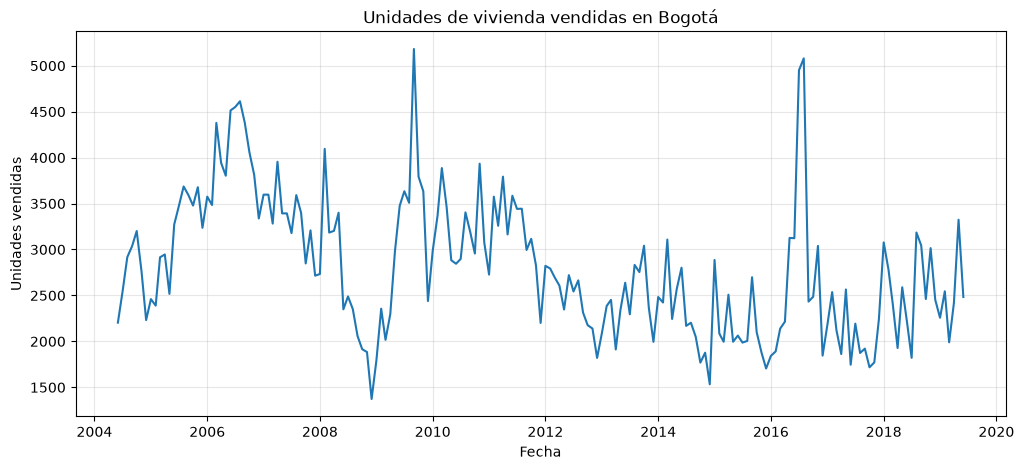

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["UNIDADES_VENDIDAS_TOTAL"])

plt.title("Unidades de vivienda vendidas en Bogotá")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.grid(alpha=0.3)

plt.show()

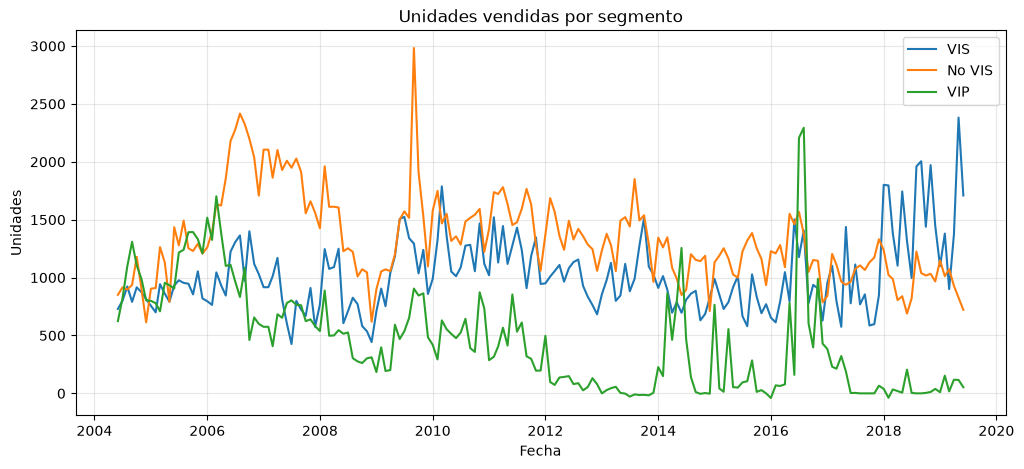

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["UNIDADES_VENDIDAS_VIS"], label="VIS")
plt.plot(df["MES"], df["UNIDADES_VENDIDAS_NO_VIS"], label="No VIS")
plt.plot(df["MES"], df["UNIDADES_VENDIDAS_VIP"], label="VIP")

plt.title("Unidades vendidas por segmento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(20)

VALOR_PROMEDIO_VIVIENDA_VIP    1
UNIDADES_VENDIDAS_TOTAL        0
UNIDADES_VENDIDAS_VIS          0
UNIDADES_VENDIDAS_VIP          0
UNIDADES_DISPONIBLES_TOTAL     0
UNIDADES_DISPONIBLES_VIP       0
UNIDADES_DISPONIBLES_VIS       0
UNIDADES_DISPONIBLES_NO_VIS    0
UNIDADES_LANZADAS_TOTAL        0
UNIDADES_LANZADAS_VIP          0
UNIDADES_LANZADAS_VIS          0
UNIDADES_VENDIDAS_NO_VIS       0
AREA_VENDIDAS_TOTAL            0
AREA_VENDIDAS_VIP              0
AREA_VENDIDAS_VIS              0
AREA_VENDIDAS_NO_VIS           0
AREA_DISPONIBLES_TOTAL         0
AREA_DISPONIBLES_VIP           0
AREA_DISPONIBLES_VIS           0
AREA_DISPONIBLES_NO_VIS        0
dtype: int64

In [44]:
df.loc[
    np.isinf(df["VALOR_PROMEDIO_VIVIENDA_VIP"]),
    [
        "MES",
        "UNIDADES_VENDIDAS_VIP",
        "VALOR_VENDIDAS_VIP",
        "VALOR_PROMEDIO_VIVIENDA_VIP"
    ]
]

,MES,UNIDADES_VENDIDAS_VIP,VALOR_VENDIDAS_VIP,VALOR_PROMEDIO_VIVIENDA_VIP
103,2013-01-01,0,-210,-inf


In [45]:
df["VALOR_PROMEDIO_VIVIENDA_VIP"] = (
    df["VALOR_PROMEDIO_VIVIENDA_VIP"]
    .replace([np.inf, -np.inf], np.nan)
)

In [46]:
np.isinf(df.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [47]:
df.isna().sum().sort_values(ascending=False).head(15)

CRECIMIENTO_VALOR_ANUAL_PCT     12
CRECIMIENTO_VENTAS_ANUAL        12
CRECIMIENTO_VALOR_ANUAL         12
CRECIMIENTO_VENTAS_ANUAL_PCT    12
VALOR_PROMEDIO_VIVIENDA_VIP      8
VALOR_M2_VIP                     7
UNIDADES_DISPONIBLES_VIP         0
UNIDADES_DISPONIBLES_TOTAL       0
MES                              0
UNIDADES_VENDIDAS_TOTAL          0
UNIDADES_VENDIDAS_VIP            0
UNIDADES_VENDIDAS_VIS            0
UNIDADES_VENDIDAS_NO_VIS         0
AREA_VENDIDAS_TOTAL              0
AREA_VENDIDAS_VIP                0
dtype: int64

10.EDA visual

ventas totales:

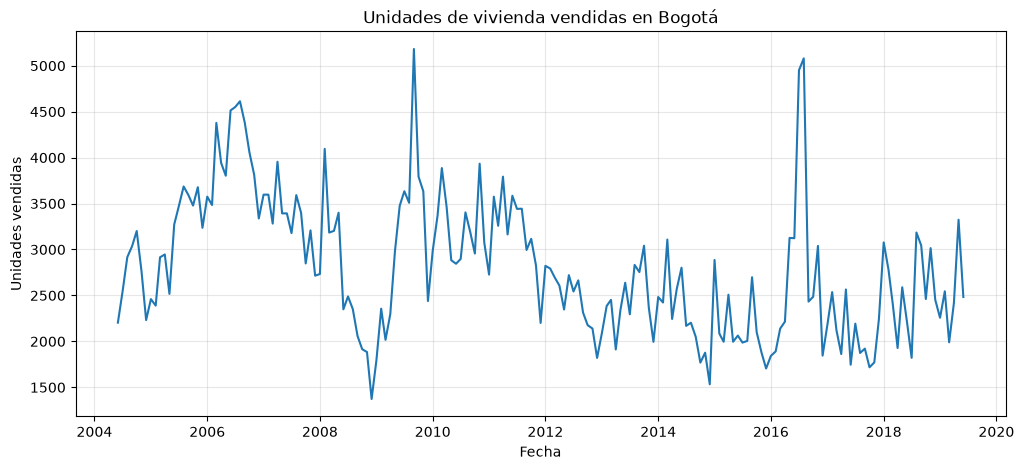

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["UNIDADES_VENDIDAS_TOTAL"])

plt.title("Unidades de vivienda vendidas en Bogotá")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.grid(alpha=0.3)

plt.show()

por segmento:

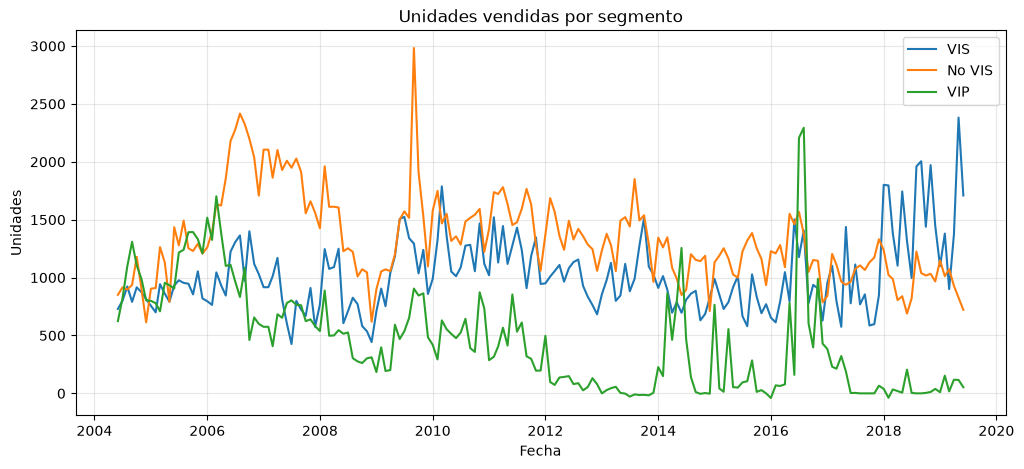

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["UNIDADES_VENDIDAS_VIS"], label="VIS")
plt.plot(df["MES"], df["UNIDADES_VENDIDAS_NO_VIS"], label="No VIS")
plt.plot(df["MES"], df["UNIDADES_VENDIDAS_VIP"], label="VIP")

plt.title("Unidades vendidas por segmento")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

valor por m²:

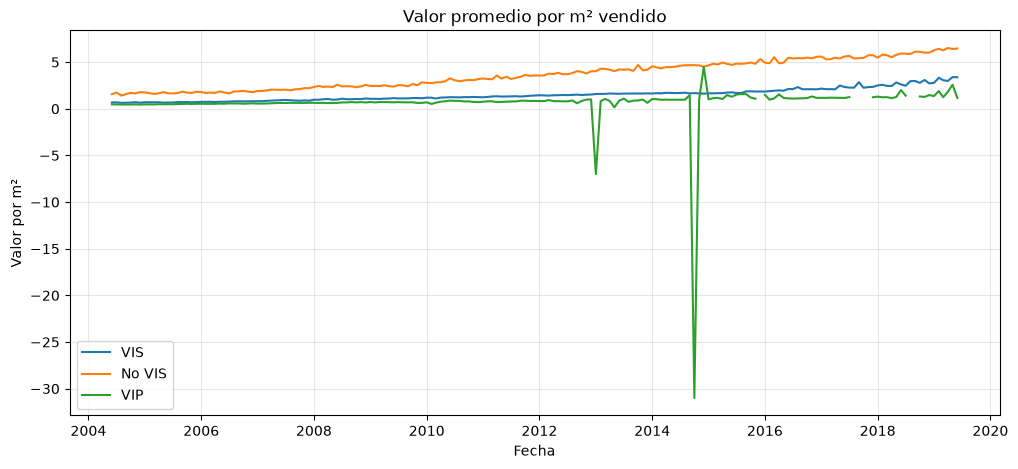

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["VALOR_M2_VIS"], label="VIS")
plt.plot(df["MES"], df["VALOR_M2_NO_VIS"], label="No VIS")
plt.plot(df["MES"], df["VALOR_M2_VIP"], label="VIP")

plt.title("Valor promedio por m² vendido")
plt.xlabel("Fecha")
plt.ylabel("Valor por m²")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

crecimiento anual:

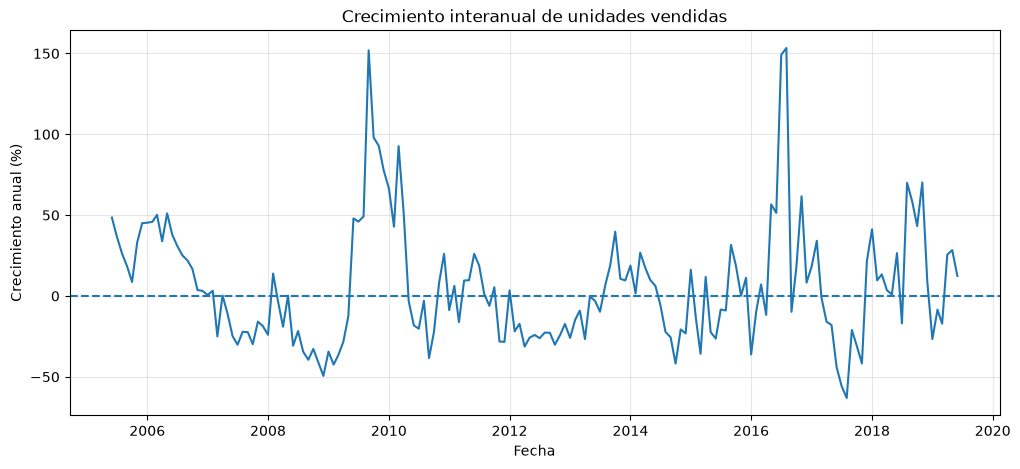

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["CRECIMIENTO_VENTAS_ANUAL_PCT"])

plt.axhline(0, linestyle="--")

plt.title("Crecimiento interanual de unidades vendidas")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento anual (%)")
plt.grid(alpha=0.3)

plt.show()

Valores negativos

In [52]:
df.loc[
    df["VALOR_M2_VIP"] < 0,
    [
        "MES",
        "VALOR_VENDIDAS_VIP",
        "AREA_VENDIDAS_VIP",
        "VALOR_M2_VIP"
    ]
]

,MES,VALOR_VENDIDAS_VIP,AREA_VENDIDAS_VIP,VALOR_M2_VIP
103,2013-01-01,-210,30,-7.0
124,2014-10-01,-186,6,-31.0


In [53]:
df.loc[
    df["VALOR_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "UNIDADES_VENDIDAS_VIP",
        "AREA_VENDIDAS_VIP",
        "VALOR_VENDIDAS_VIP"
    ]
]

,MES,UNIDADES_VENDIDAS_VIP,AREA_VENDIDAS_VIP,VALOR_VENDIDAS_VIP
103,2013-01-01,0,30,-210
108,2013-06-01,-2,-324,-280
109,2013-07-01,-28,-1485,-1622
110,2013-08-01,-9,-495,-368
111,2013-09-01,-14,-909,-799
112,2013-10-01,-13,-830,-739
113,2013-11-01,-17,-961,-949
114,2013-12-01,5,-107,-68
124,2014-10-01,-4,6,-186
126,2014-12-01,-3,-34,-152


In [54]:
df.loc[
    df["AREA_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "UNIDADES_VENDIDAS_VIP",
        "AREA_VENDIDAS_VIP",
        "VALOR_VENDIDAS_VIP"
    ]
]

,MES,UNIDADES_VENDIDAS_VIP,AREA_VENDIDAS_VIP,VALOR_VENDIDAS_VIP
108,2013-06-01,-2,-324,-280
109,2013-07-01,-28,-1485,-1622
110,2013-08-01,-9,-495,-368
111,2013-09-01,-14,-909,-799
112,2013-10-01,-13,-830,-739
113,2013-11-01,-17,-961,-949
114,2013-12-01,5,-107,-68
126,2014-12-01,-3,-34,-152
139,2016-01-01,-40,-1320,-1972
164,2018-02-01,-38,-1660,-2044


Valores imposibles

In [55]:
columnas_numericas = df.select_dtypes(include=np.number).columns

negativos = (df[columnas_numericas] < 0).sum()

negativos[negativos > 0].sort_values(ascending=False)

CRECIMIENTO_VENTAS_ANUAL        82
CRECIMIENTO_VENTAS_ANUAL_PCT    82
CRECIMIENTO_VALOR_ANUAL         69
CRECIMIENTO_VALOR_ANUAL_PCT     69
DIF_VALOR_LANZADAS              26
DIF_AREA_LANZADAS               17
VALOR_VENDIDAS_VIP              12
UNIDADES_VENDIDAS_VIP           10
TASA_ABSORCION_VIP              10
PARTICIPACION_VIP               10
VALOR_LANZADAS_VIP              10
AREA_VENDIDAS_VIP               10
UNIDADES_LANZADAS_VIP            9
AREA_LANZADAS_VIP                9
VALOR_M2_VIP                     2
VALOR_PROMEDIO_VIVIENDA_VIP      1
dtype: int64

In [56]:
df[
    [
        "MES",
        "UNIDADES_VENDIDAS_TOTAL",
        "UNIDADES_VENDIDAS_VIS",
        "UNIDADES_VENDIDAS_NO_VIS",
        "UNIDADES_VENDIDAS_VIP"
    ]
].describe()

,MES,UNIDADES_VENDIDAS_TOTAL,UNIDADES_VENDIDAS_VIS,UNIDADES_VENDIDAS_NO_VIS,UNIDADES_VENDIDAS_VIP
count,181,181.000000,181.000000,181.000000,181.000000
mean,2011-12-01 05:58:00.662983,2801.419890,1020.011050,1330.441989,450.966851
min,2004-06-01 00:00:00,1373.000000,426.000000,614.000000,-40.000000
25%,2008-03-01 00:00:00,2209.000000,796.000000,1059.000000,57.000000
50%,2011-12-01 00:00:00,2721.000000,954.000000,1261.000000,383.000000
75%,2015-09-01 00:00:00,3282.000000,1170.000000,1543.000000,709.000000
max,2019-06-01 00:00:00,5182.000000,2382.000000,2983.000000,2294.000000
std,NaN,742.227294,319.469717,379.230146,446.329050


VERIFICACION

In [57]:
df.loc[
    df["UNIDADES_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "UNIDADES_VENDIDAS_TOTAL",
        "UNIDADES_VENDIDAS_VIS",
        "UNIDADES_VENDIDAS_NO_VIS",
        "UNIDADES_VENDIDAS_VIP"
    ]
]

,MES,UNIDADES_VENDIDAS_TOTAL,UNIDADES_VENDIDAS_VIS,UNIDADES_VENDIDAS_NO_VIS,UNIDADES_VENDIDAS_VIP
108,2013-06-01,2638,1118,1522,-2
109,2013-07-01,2295,882,1441,-28
110,2013-08-01,2832,990,1851,-9
111,2013-09-01,2754,1274,1494,-14
112,2013-10-01,3041,1516,1538,-13
113,2013-11-01,2367,1095,1289,-17
124,2014-10-01,1769,631,1142,-4
126,2014-12-01,1533,825,711,-3
139,2016-01-01,1842,654,1228,-40
164,2018-02-01,2781,1796,1023,-38


In [58]:
df.loc[
    df["AREA_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "AREA_VENDIDAS_TOTAL",
        "AREA_VENDIDAS_VIS",
        "AREA_VENDIDAS_NO_VIS",
        "AREA_VENDIDAS_VIP"
    ]
]

,MES,AREA_VENDIDAS_TOTAL,AREA_VENDIDAS_VIS,AREA_VENDIDAS_NO_VIS,AREA_VENDIDAS_VIP
108,2013-06-01,180452,56451,124324,-324
109,2013-07-01,155921,44397,113009,-1485
110,2013-08-01,198209,50248,148455,-495
111,2013-09-01,181651,63468,119093,-909
112,2013-10-01,202454,75244,128040,-830
113,2013-11-01,151362,55086,97236,-961
114,2013-12-01,123860,51240,72727,-107
126,2014-12-01,98321,42357,55998,-34
139,2016-01-01,120343,31525,90138,-1320
164,2018-02-01,150647,79993,72314,-1660


In [59]:
df.loc[
    df["VALOR_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "VALOR_VENDIDAS_TOTAL",
        "VALOR_VENDIDAS_VIS",
        "VALOR_VENDIDAS_NO_VIS",
        "VALOR_VENDIDAS_VIP"
    ]
]

,MES,VALOR_VENDIDAS_TOTAL,VALOR_VENDIDAS_VIS,VALOR_VENDIDAS_NO_VIS,VALOR_VENDIDAS_VIP
103,2013-01-01,476755,67643,409321,-210
108,2013-06-01,615623,90679,525223,-280
109,2013-07-01,543875,72284,473214,-1622
110,2013-08-01,708502,82163,626707,-368
111,2013-09-01,587391,104542,483648,-799
112,2013-10-01,724200,123465,601474,-739
113,2013-11-01,489234,89956,400227,-949
114,2013-12-01,389413,84527,304954,-68
124,2014-10-01,495784,52330,443640,-186
126,2014-12-01,321163,68721,252594,-152


In [60]:
check_vip_unidades = (
    df["UNIDADES_VENDIDAS_TOTAL"]
    - df["UNIDADES_VENDIDAS_VIS"]
    - df["UNIDADES_VENDIDAS_NO_VIS"]
)

(check_vip_unidades == df["UNIDADES_VENDIDAS_VIP"]).value_counts()

True    181
Name: count, dtype: int64

In [61]:
df.loc[
    df["UNIDADES_VENDIDAS_VIP"] < 0,
    [
        "MES",
        "UNIDADES_VENDIDAS_TOTAL",
        "UNIDADES_VENDIDAS_VIS",
        "UNIDADES_VENDIDAS_NO_VIS",
        "UNIDADES_VENDIDAS_VIP"
    ]
].assign(
    VIP_CALCULADO=lambda x:
        x["UNIDADES_VENDIDAS_TOTAL"]
        - x["UNIDADES_VENDIDAS_VIS"]
        - x["UNIDADES_VENDIDAS_NO_VIS"]
)

,MES,UNIDADES_VENDIDAS_TOTAL,UNIDADES_VENDIDAS_VIS,UNIDADES_VENDIDAS_NO_VIS,UNIDADES_VENDIDAS_VIP,VIP_CALCULADO
108,2013-06-01,2638,1118,1522,-2,-2
109,2013-07-01,2295,882,1441,-28,-28
110,2013-08-01,2832,990,1851,-9,-9
111,2013-09-01,2754,1274,1494,-14,-14
112,2013-10-01,3041,1516,1538,-13,-13
113,2013-11-01,2367,1095,1289,-17,-17
124,2014-10-01,1769,631,1142,-4,-4
126,2014-12-01,1533,825,711,-3,-3
139,2016-01-01,1842,654,1228,-40,-40
164,2018-02-01,2781,1796,1023,-38,-38


### Nota metodológica sobre el segmento VIP

Se verificó que `UNIDADES_VENDIDAS_VIP` es exactamente igual a:

`UNIDADES_VENDIDAS_TOTAL - UNIDADES_VENDIDAS_VIS - UNIDADES_VENDIDAS_NO_VIS`

para los 181 meses observados.

Por tanto, VIP se comporta como una categoría residual. En algunos meses toma valores negativos cuando la suma de VIS y No VIS supera al total reportado.

Por esta razón, los indicadores derivados de VIP no se utilizan como parte principal del análisis.

1. Participación VIS vs No VIS

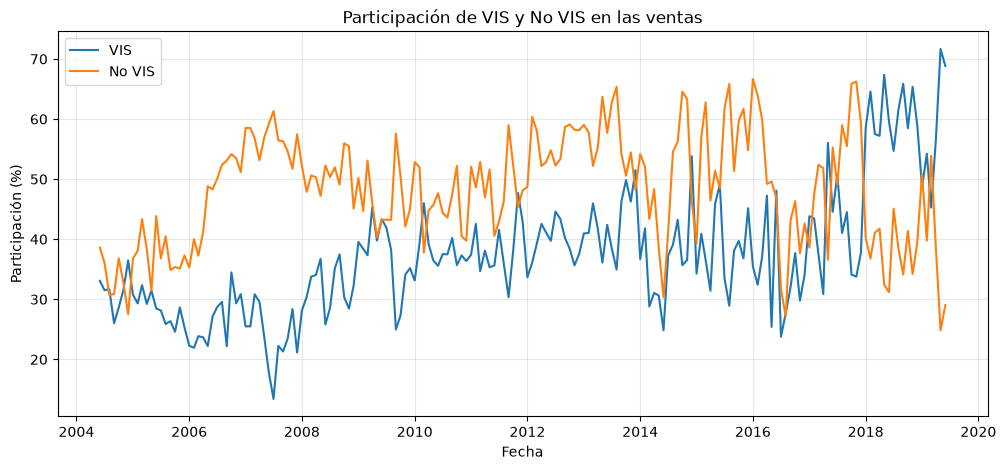

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["PARTICIPACION_VIS"] * 100, label="VIS")
plt.plot(df["MES"], df["PARTICIPACION_NO_VIS"] * 100, label="No VIS")

plt.title("Participación de VIS y No VIS en las ventas")
plt.xlabel("Fecha")
plt.ylabel("Participación (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

2. Tasa de absorción

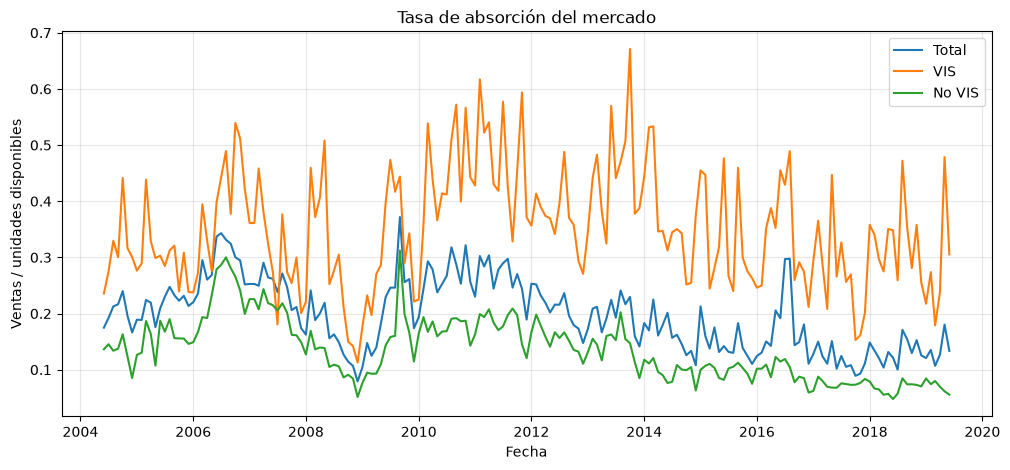

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["TASA_ABSORCION_TOTAL"], label="Total")
plt.plot(df["MES"], df["TASA_ABSORCION_VIS"], label="VIS")
plt.plot(df["MES"], df["TASA_ABSORCION_NO_VIS"], label="No VIS")

plt.title("Tasa de absorción del mercado")
plt.xlabel("Fecha")
plt.ylabel("Ventas / unidades disponibles")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

3. Crecimiento interanual de ventas

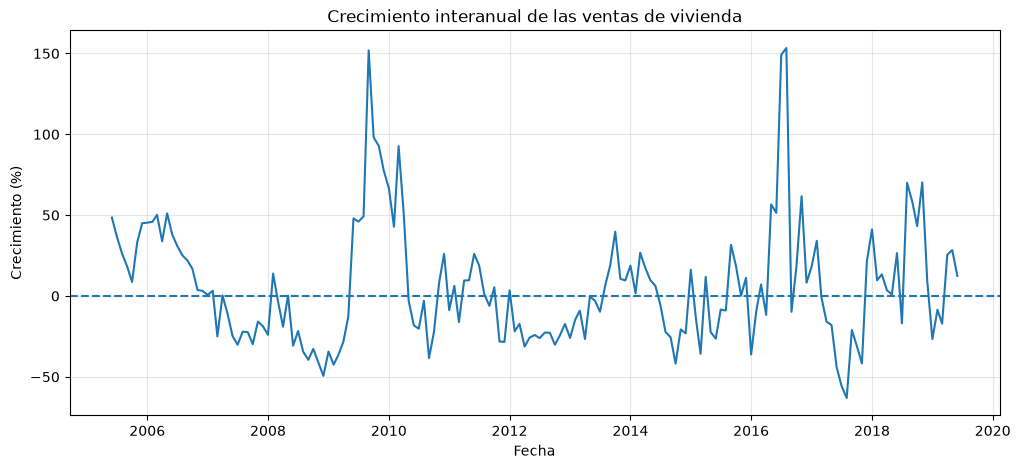

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["CRECIMIENTO_VENTAS_ANUAL_PCT"])
plt.axhline(0, linestyle="--")

plt.title("Crecimiento interanual de las ventas de vivienda")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento (%)")
plt.grid(alpha=0.3)

plt.show()

4. Valor por m², solo VIS y No VIS

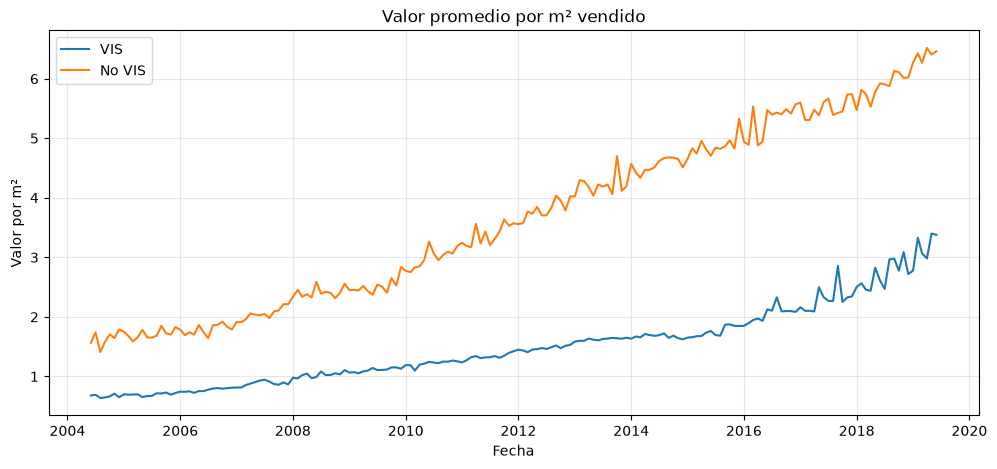

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(df["MES"], df["VALOR_M2_VIS"], label="VIS")
plt.plot(df["MES"], df["VALOR_M2_NO_VIS"], label="No VIS")

plt.title("Valor promedio por m² vendido")
plt.xlabel("Fecha")
plt.ylabel("Valor por m²")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [66]:
df["AÑO"] = df["MES"].dt.year

Ventas totales por año

In [67]:
ventas_anuales = (
    df.groupby("AÑO")["UNIDADES_VENDIDAS_TOTAL"]
    .sum()
    .sort_values(ascending=False)
)

ventas_anuales

AÑO
2006    48451
2007    40157
2010    38885
2011    38126
2005    37642
2009    37105
2016    34169
2008    31034
2018    30965
2012    29642
2013    29101
2014    27231
2015    25909
2017    24729
2004    18893
2019    15018
Name: UNIDADES_VENDIDAS_TOTAL, dtype: int64

Mejor y peor año

In [68]:
print("Mejor año:", ventas_anuales.idxmax(), ventas_anuales.max())
print("Peor año:", ventas_anuales.idxmin(), ventas_anuales.min())

Mejor año: 2006 48451
Peor año: 2019 15018


Mes con más ventas y mes con menos ventas

In [69]:
fila_max = df.loc[df["UNIDADES_VENDIDAS_TOTAL"].idxmax()]
fila_min = df.loc[df["UNIDADES_VENDIDAS_TOTAL"].idxmin()]

print("Mes con más ventas:")
print(fila_max[["MES", "UNIDADES_VENDIDAS_TOTAL"]])

print("\nMes con menos ventas:")
print(fila_min[["MES", "UNIDADES_VENDIDAS_TOTAL"]])

Mes con más ventas:
MES                        2009-09-01 00:00:00
UNIDADES_VENDIDAS_TOTAL                   5182
Name: 63, dtype: object

Mes con menos ventas:
MES                        2008-12-01 00:00:00
UNIDADES_VENDIDAS_TOTAL                   1373
Name: 54, dtype: object


Promedio anual de ventas

In [70]:
promedio_anual = (
    df.groupby("AÑO")["UNIDADES_VENDIDAS_TOTAL"]
    .mean()
)

promedio_anual

AÑO
2004    2699.000000
2005    3136.833333
2006    4037.583333
2007    3346.416667
2008    2586.166667
2009    3092.083333
2010    3240.416667
2011    3177.166667
2012    2470.166667
2013    2425.083333
2014    2269.250000
2015    2159.083333
2016    2847.416667
2017    2060.750000
2018    2580.416667
2019    2503.000000
Name: UNIDADES_VENDIDAS_TOTAL, dtype: float64

VIS vs No VIS por año

In [71]:
segmentos_anuales = (
    df.groupby("AÑO")[
        ["UNIDADES_VENDIDAS_VIS", "UNIDADES_VENDIDAS_NO_VIS"]
    ]
    .sum()
)

segmentos_anuales

,UNIDADES_VENDIDAS_VIS,UNIDADES_VENDIDAS_NO_VIS
AÑO,,
2004,5846,6297
2005,10592,14185
2006,12797,22911
2007,9532,22778
2008,9903,15664
2009,13389,17391
2010,14810,17663
2011,14570,18557
2012,11671,16417


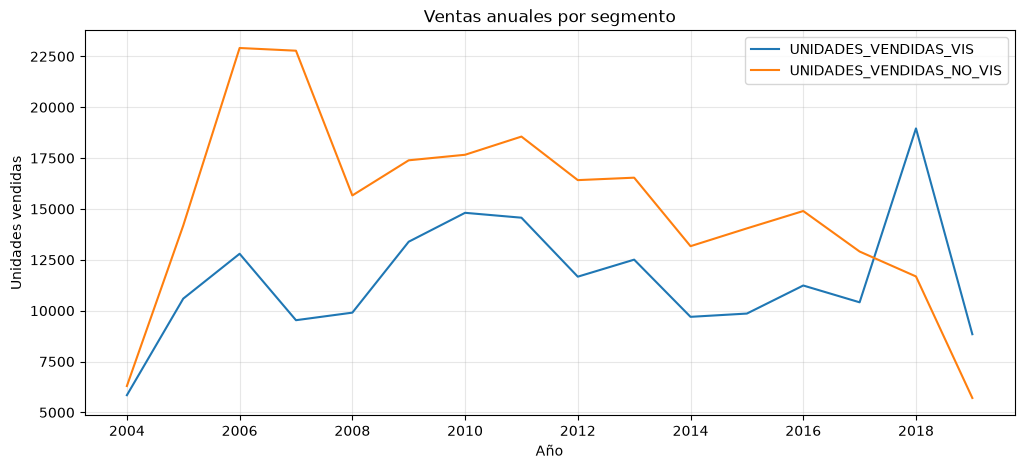

In [72]:
segmentos_anuales.plot(figsize=(12, 5))

plt.title("Ventas anuales por segmento")
plt.xlabel("Año")
plt.ylabel("Unidades vendidas")
plt.grid(alpha=0.3)

plt.show()

In [73]:
conteo_meses = df.groupby("AÑO")["MES"].count()

años_completos = conteo_meses[conteo_meses == 12].index

ventas_anuales_completas = (
    df[df["AÑO"].isin(años_completos)]
    .groupby("AÑO")["UNIDADES_VENDIDAS_TOTAL"]
    .sum()
)

print("Mejor año completo:",
      ventas_anuales_completas.idxmax(),
      ventas_anuales_completas.max())

print("Peor año completo:",
      ventas_anuales_completas.idxmin(),
      ventas_anuales_completas.min())

Mejor año completo: 2006 48451
Peor año completo: 2017 24729


### Nota sobre 2019

El dataset finaliza en junio de 2019, por lo que ese año contiene únicamente seis meses de observaciones. Por esta razón, 2019 no se utiliza para comparar ventas anuales acumuladas frente a años completos.

In [74]:
caida = (24729 / 48451 - 1) * 100
caida

-48.960805762522966

### Ventas anuales

Entre los años completos disponibles en el dataset, 2006 registró el mayor volumen de ventas, con 48.451 unidades, mientras que 2017 presentó el menor, con 24.729 unidades.

Esto representa una reducción aproximada del 49 % entre ambos niveles.

El año 2019 fue excluido de esta comparación debido a que el dataset solo contiene información hasta junio de ese año.

comportamiento temporal

In [75]:
df["MES_NUM"] = df["MES"].dt.month

In [76]:
promedio_por_mes = (
    df.groupby("MES_NUM")["UNIDADES_VENDIDAS_TOTAL"]
    .mean()
)

promedio_por_mes

MES_NUM
1     2633.933333
2     2820.000000
3     2788.266667
4     2752.866667
5     2866.266667
6     2839.000000
7     2944.000000
8     3157.266667
9     3003.000000
10    2741.200000
11    2788.600000
12    2280.133333
Name: UNIDADES_VENDIDAS_TOTAL, dtype: float64

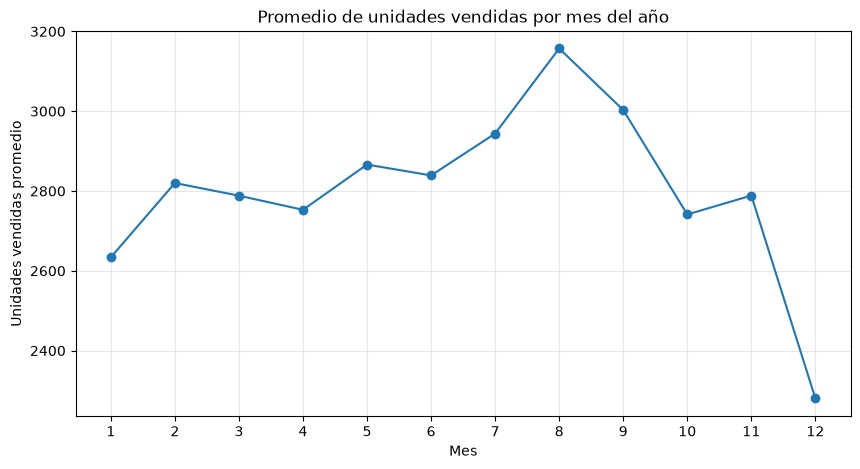

In [77]:
plt.figure(figsize=(10, 5))

plt.plot(promedio_por_mes.index, promedio_por_mes.values, marker="o")

plt.title("Promedio de unidades vendidas por mes del año")
plt.xlabel("Mes")
plt.ylabel("Unidades vendidas promedio")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.show()

media móvil de 12 meses

In [78]:
df["MEDIA_MOVIL_12M"] = (
    df["UNIDADES_VENDIDAS_TOTAL"]
    .rolling(window=12)
    .mean()
)

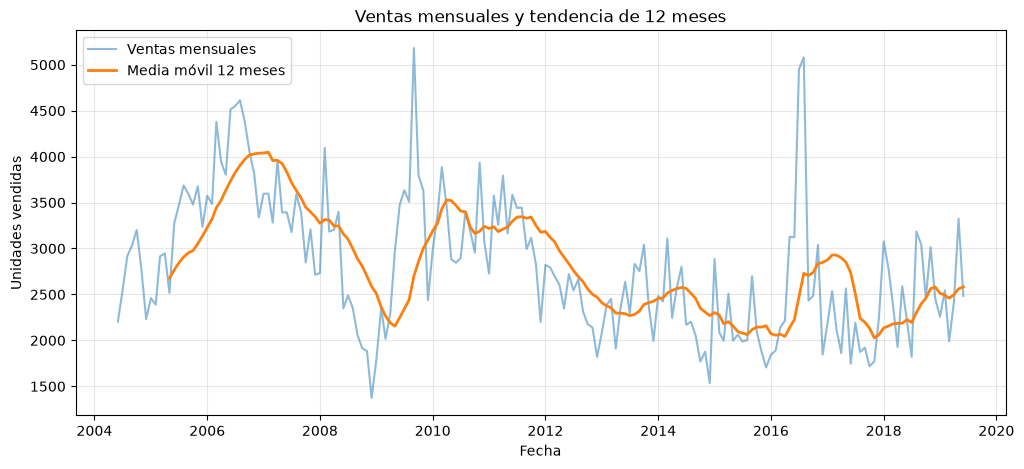

In [79]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["MES"],
    df["UNIDADES_VENDIDAS_TOTAL"],
    alpha=0.5,
    label="Ventas mensuales"
)

plt.plot(
    df["MES"],
    df["MEDIA_MOVIL_12M"],
    linewidth=2,
    label="Media móvil 12 meses"
)

plt.title("Ventas mensuales y tendencia de 12 meses")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

descomposición estacional

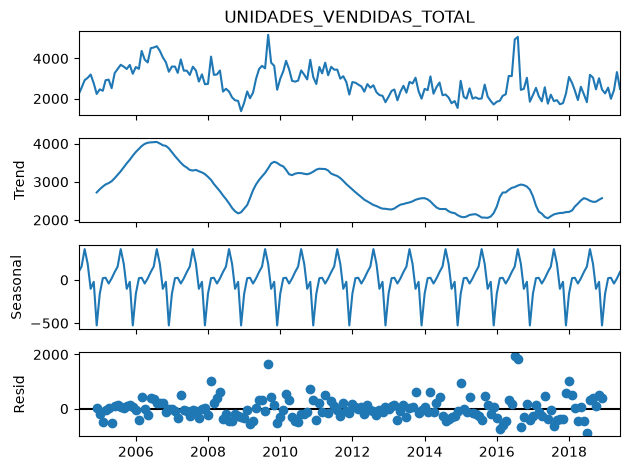

In [80]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie = (
    df.set_index("MES")["UNIDADES_VENDIDAS_TOTAL"]
    .asfreq("MS")
)

descomposicion = seasonal_decompose(
    serie,
    model="additive",
    period=12
)

descomposicion.plot()
plt.show()

### Estacionalidad mensual

El mercado presenta un patrón estacional visible. Agosto y septiembre registran los mayores niveles promedio de ventas, mientras que diciembre muestra el menor volumen.

Esto sugiere que el mes del año aporta información relevante para explicar y pronosticar las ventas de vivienda.

### Conclusiones del análisis temporal

La serie de ventas de vivienda en Bogotá presenta tres características principales:

1. Existe una estacionalidad anual identificable, con mayores ventas promedio en agosto y septiembre y menores niveles en diciembre.
2. La tendencia de largo plazo no es lineal y presenta distintos ciclos de expansión y contracción.
3. Existen meses con variaciones extraordinarias que generan residuos elevados, lo que indica la presencia de shocks que no son explicados únicamente por tendencia y estacionalidad.

Estas características justifican el uso de modelos de series de tiempo capaces de incorporar estacionalidad y dinámica temporal.